---
title: "PINN for Glioblastoma"
date: 2026-01-15
status: "Experiment"
tags: ["AI", "Research", "PINN"]
---

# PINN for Glioblastoma

This is a fun exploration I did about Physics Informed Neural Networks.



In [ ]:
!pip install nibabel matplotlib numpy torch

In [ ]:
import kagglehub

path = kagglehub.dataset_download("awsaf49/brats2020-training-data")

print("Path to dataset files:", path)

100%|██████████| 6.76G/6.76G [01:02<00:00, 117MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/awsaf49/brats2020-training-data/versions/3


In [ ]:
import nibabel as nib
import matplotlib.pyplot as plt
import numpy as np
import os
import glob
import h5py
import pandas as pd

In [ ]:
h5_files = sorted(glob.glob(path + "/**/*.h5", recursive=True))
print("Total slices:", len(h5_files))

Total slices: 57195


In [ ]:
trial_file = h5_files[2000]
print(trial_file)

/root/.cache/kagglehub/datasets/awsaf49/brats2020-training-data/versions/3/BraTS2020_training_data/content/data/volume_111_slice_86.h5


                                          slice_path  target  volume  slice  \
0  ../input/brats2020-training-data/BraTS2020_tra...       0      41      0   
1  ../input/brats2020-training-data/BraTS2020_tra...       0      41      1   
2  ../input/brats2020-training-data/BraTS2020_tra...       0      41      2   
3  ../input/brats2020-training-data/BraTS2020_tra...       0      41      3   
4  ../input/brats2020-training-data/BraTS2020_tra...       0      41      4   

   label0_pxl_cnt  label1_pxl_cnt  label2_pxl_cnt  background_ratio  
0               0               0               0               1.0  
1               0               0               0               1.0  
2               0               0               0               1.0  
3               0               0               0               1.0  
4               0               0               0               1.0  
slice_path          ../input/brats2020-training-data/BraTS2020_tra...
target                             

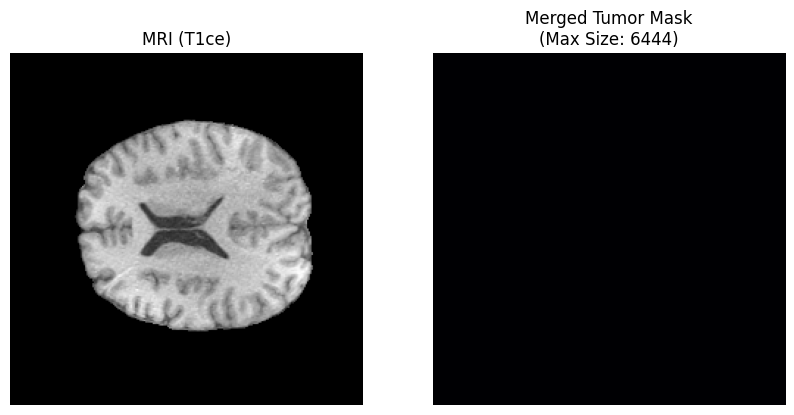

In [ ]:
metadata = pd.read_csv(path + '/BraTS20 Training Metadata.csv')
print(metadata.head())

tumour_df = metadata[metadata['target']==1].copy()
tumour_df['total'] = tumour_df['label0_pxl_cnt'] +tumour_df['label1_pxl_cnt'] + tumour_df['label2_pxl_cnt']
best_row = tumour_df.sort_values(by='total', ascending=False).iloc[0]
print(best_row)
print(tumour_df.head())

with h5py.File(trial_file, "r") as f:
  img_data = f['image'][:]
  mask_data = f['mask'][:]

  print(img_data.shape)
  print(mask_data.shape)

if img_data.ndim == 3 and img_data.shape[-1] == 4:
  img_data = np.moveaxis(img_data, -1, 0)

u0 = np.max(mask_data, axis=-1).astype(np.float32)
fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(img_data[1], cmap='gray')
axes[0].set_title("MRI (T1ce)")
axes[0].axis('off')

axes[1].imshow(u0, cmap='magma')
axes[1].set_title(f"Merged Tumor Mask\n(Max Size: {best_row['total']})")
axes[1].axis('off')

plt.show()






Step 1: finding all .h5 files...
Found 57195 total files.
Step 2: Hunting for a massive tumor directly in the files...
 > Found candidate! Size: 2857 pixels
 > Found candidate! Size: 4272 pixels
 > Found candidate! Size: 4495 pixels
 > Found candidate! Size: 4819 pixels
 > Found candidate! Size: 4883 pixels
 > Found candidate! Size: 6263 pixels
 > Excellent candidate found. Stopping search.

WINNER FOUND: /root/.cache/kagglehub/datasets/awsaf49/brats2020-training-data/versions/3/BraTS2020_training_data/content/data/volume_328_slice_84.h5
Tumor Size: 6263 pixels


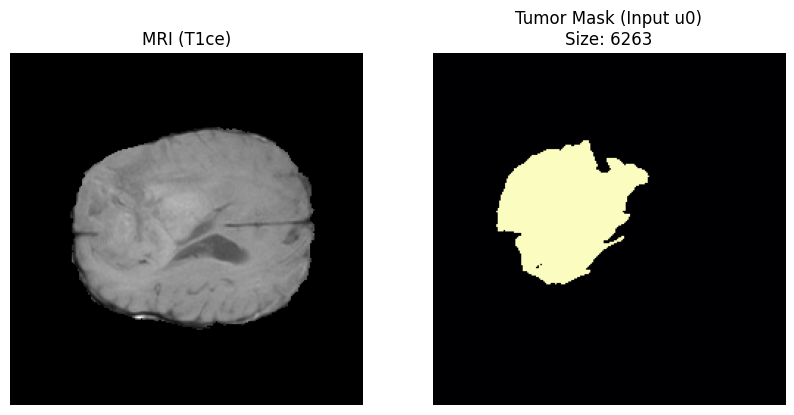

Saved 'best_tumor_slice.npy'. You are ready to train.


In [ ]:
import h5py
import numpy as np
import matplotlib.pyplot as plt
import os
import glob
import random

dataset_root = path

print("Step 1: finding all .h5 files...")
# Get ALL .h5 files recursively
all_files = glob.glob(os.path.join(dataset_root, '**', '*.h5'), recursive=True)
print(f"Found {len(all_files)} total files.")

# Randomize them so we don't get stuck in one patient
random.shuffle(all_files)

print("Step 2: Hunting for a massive tumor directly in the files...")

best_slice = None
max_tumor_size = 0
files_checked = 0

# Scan up to 500 files to find the absolute best one
for file_path in all_files[:500]:
    try:
        with h5py.File(file_path, 'r') as f:
            # We only need the mask to check size
            mask = f['mask'][:]

        # Fix 3-channel issue (flatten it)
        tumor_map = np.max(mask, axis=-1)

        # Count pixels
        current_size = np.count_nonzero(tumor_map)

        # If this is the biggest we've seen, save it
        if current_size > max_tumor_size:
            max_tumor_size = current_size
            best_slice = (file_path, tumor_map)
            print(f" > Found candidate! Size: {current_size} pixels")

            # If it's huge (>5000 pixels), stop searching immediately. We found a winner.
            if current_size > 5000:
                print(" > Excellent candidate found. Stopping search.")
                break

        files_checked += 1

    except Exception as e:
        continue

# --- VISUALIZE THE WINNER ---
if best_slice:
    file_path, u0 = best_slice
    print(f"\nWINNER FOUND: {file_path}")
    print(f"Tumor Size: {max_tumor_size} pixels")

    # Load the image for the winner
    with h5py.File(file_path, 'r') as f:
        img_data = f['image'][:]

    # Fix image shape if needed
    if img_data.shape[-1] == 4:
        img_data = np.moveaxis(img_data, -1, 0)

    # Plot
    fig, axes = plt.subplots(1, 2, figsize=(10, 5))

    # MRI
    axes[0].imshow(img_data[1], cmap='gray') # T1ce channel
    axes[0].set_title("MRI (T1ce)")
    axes[0].axis('off')

    # Tumor
    axes[1].imshow(u0, cmap='magma')
    axes[1].set_title(f"Tumor Mask (Input u0)\nSize: {max_tumor_size}")
    axes[1].axis('off')

    plt.show()

    np.save('best_tumor_slice.npy', u0)
    print("Saved 'best_tumor_slice.npy'. You are ready to train.")

else:
    print("Checked 500 files but found no tumors. Attempting to scan 500 more...")

Using: cuda
(240, 240)
Ground Truth Data Generated. Shape: (7, 240, 240)


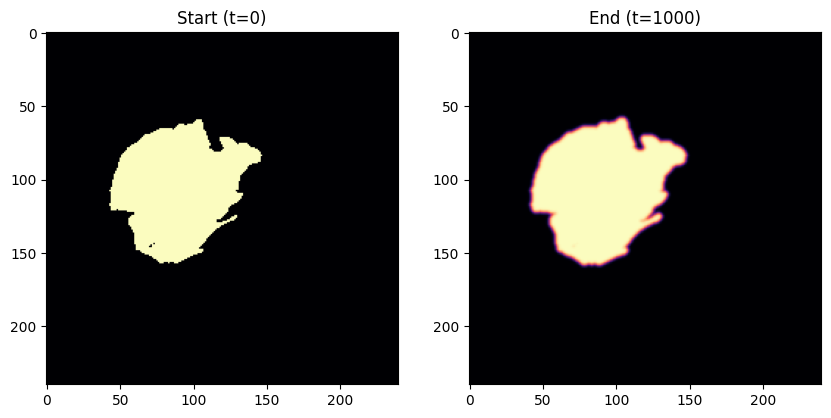

In [ ]:
import torch
import torch.nn as nn
import time


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using: {device}")

u0 = np.load('best_tumor_slice.npy')
print(u0.shape)


D_true = 0.02
rho_true = 0.15
dt = 0.03
T_steps = 1000

u_sim = [u0.copy()]
u_curr = u0.copy()
brain_mask = np.ones_like(u0)

for t in range(T_steps):
  uxx = np.roll(u_curr, 1, axis=0) + np.roll(u_curr, -1, axis=0) + np.roll(u_curr, 1, axis=1) - 2*u_curr + np.roll(u_curr, -1, axis=1) - 4 * u_curr
  reaction = rho_true * u_curr * (1 - u_curr)
  u_next = u_curr + dt * (D_true * uxx + reaction)
  u_curr = u_next * brain_mask

  if t % 200 == 0:
    u_sim.append(u_curr.copy())

u_sim.append(u_curr.copy())
u_data = np.array(u_sim)

print(f"Ground Truth Data Generated. Shape: {u_data.shape}")

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(u_data[0], cmap='magma'); axes[0].set_title("Start (t=0)")
axes[1].imshow(u_data[-1], cmap='magma'); axes[1].set_title("End (t=1000)")
plt.show()

In [ ]:
H, W = u0.shape
# Create normalized coordinates (-1 to 1)
x_coords = np.linspace(-1, 1, W)
y_coords = np.linspace(-1, 1, H)
t_coords = np.linspace(0, 1, len(u_data)) # Normalized time 0.0 to 1.0

# Create the Grid
X_grid, Y_grid = np.meshgrid(x_coords, y_coords)

inputs_list = []
targets_list = []

for i, t_val in enumerate(t_coords):
    # Flatten the image for this time step
    u_flat = u_data[i].flatten()

    # OPTIMIZATION TIP:
    # Training on 50,000 black pixels (empty brain) is a waste of time.
    # We filter to keep:
    # 1. All pixels with Tumor (u > 0.01)
    # 2. A random 5% sample of the background (to learn "empty space")
    mask_indices = (u_flat > 0.01) | (np.random.rand(len(u_flat)) < 0.05)

    # Extract coordinates for these chosen pixels
    x_flat = X_grid.flatten()[mask_indices]
    y_flat = Y_grid.flatten()[mask_indices]
    t_flat = np.full_like(x_flat, t_val)
    u_target = u_flat[mask_indices]

    # Stack them: [x, y, t]
    current_inputs = np.stack([x_flat, y_flat, t_flat], axis=1)

    inputs_list.append(current_inputs)
    targets_list.append(u_target)

# Combine all time steps into one giant training set
X_train = np.concatenate(inputs_list, axis=0)
Y_train = np.concatenate(targets_list, axis=0)

# Convert to PyTorch Tensors and move to GPU
X_train = torch.tensor(X_train, dtype=torch.float32).to(device)
Y_train = torch.tensor(Y_train, dtype=torch.float32).unsqueeze(1).to(device)

print(f"Ready for Training! Total Active Data Points: {len(X_train)}")


--- Step 2: Converting to Tensors ---
Ready for Training! Total Active Data Points: 66632


In [ ]:
import torch
import torch.nn as nn

# Define the Neural Network Class
class TumorPINN(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(3, 128), nn.Tanh()
            , nn.Linear(128, 128)
            , nn.Tanh()
            , nn.Linear(128,1)
            , nn.Sigmoid()
        )

    def forward(self, x):
        # Pass the input 'x' through the network
        return self.net(x)

# Move model to GPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = TumorPINN().to(device)
print(model)

TumorPINN(
  (net): Sequential(
    (0): Linear(in_features=3, out_features=128, bias=True)
    (1): Tanh()
    (2): Linear(in_features=128, out_features=128, bias=True)
    (3): Tanh()
    (4): Linear(in_features=128, out_features=1, bias=True)
    (5): Sigmoid()
  )
)



--- Starting PINN Training ---
Epoch 0 | Loss: 0.191531
Epoch 200 | Loss: 0.036958
Epoch 400 | Loss: 0.024586
Epoch 600 | Loss: 0.020361
Epoch 800 | Loss: 0.017386
Epoch 1000 | Loss: 0.015553
Epoch 1200 | Loss: 0.014382
Epoch 1400 | Loss: 0.013497
Epoch 1600 | Loss: 0.012690
Epoch 1800 | Loss: 0.011920
Epoch 2000 | Loss: 0.011044
Training finished in 9.6 seconds.


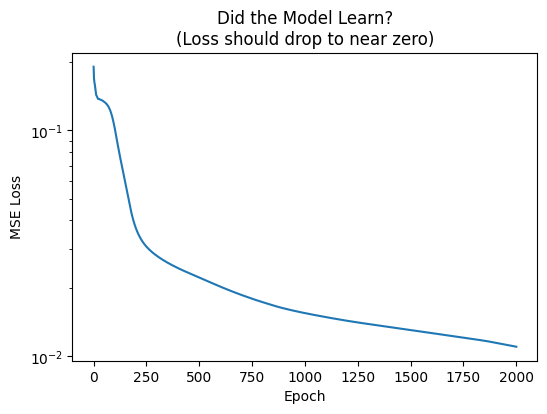

In [ ]:
import time
model = TumorPINN().to(device)

# Adam is a smart optimizer that adjusts learning speed automatically
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
loss_fn = nn.MSELoss()

start_time = time.time()
epochs = 2000 # 2000 iterations is usually enough for 2D physics
loss_history = []

for epoch in range(epochs + 1):
    # 1. Clear old gradients (PyTorch accumulates them by default)
    optimizer.zero_grad()

    # 2. Forward Pass: Ask the model for predictions
    u_pred = model(X_train)

    # 3. Calculate Loss: How wrong is the model?
    loss = loss_fn(u_pred, Y_train)

    # 4. Backward Pass: Calculate corrections (gradients)
    loss.backward()

    # 5. Step: Update the model weights
    optimizer.step()

    # Track performance
    loss_history.append(loss.item())

    # Print progress every 200 epochs
    if epoch % 200 == 0:
        print(f"Epoch {epoch} | Loss: {loss.item():.6f}")

print(f"Training finished in {time.time() - start_time:.1f} seconds.")

plt.figure(figsize=(6, 4))
plt.plot(loss_history)
plt.yscale('log') # Log scale shows the progress better when loss gets tiny
plt.title("Did the Model Learn?\n(Loss should drop to near zero)")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.show()

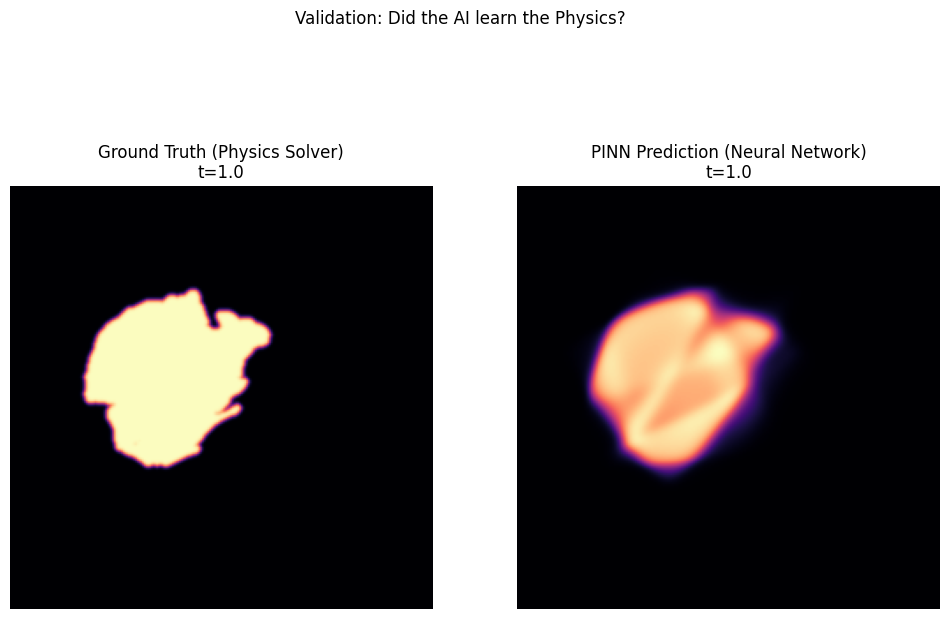

In [ ]:
# 1. Set model to evaluation mode (turns off training-specific randomness)
model.eval()

# 2. Prepare the Input Grid for t = 1.0 (The Final State)
# We recycle the grid you made earlier
full_t = np.ones_like(X_grid) * 1.0

# Flatten and convert to Tensor (same process as training data)
X_plot = X_grid.flatten()
Y_plot = Y_grid.flatten()
T_plot = full_t.flatten()

# Stack inputs [x, y, t]
plot_inputs = np.stack([X_plot, Y_plot, T_plot], axis=1)
plot_tensor = torch.tensor(plot_inputs, dtype=torch.float32).to(device)

# 3. Ask the AI for the prediction
with torch.no_grad():
    u_pred = model(plot_tensor).cpu().numpy()

# 4. Reshape back to image (Height x Width)
u_pred_img = u_pred.reshape(H, W)

# 5. Plot Comparison
fig, axes = plt.subplots(1, 2, figsize=(12, 8))

# Ground Truth (from your simulation array)
axes[0].imshow(u_data[-1], cmap='magma')
axes[0].set_title("Ground Truth (Physics Solver)\nt=1.0")
axes[0].axis('off')

# AI Prediction
axes[1].imshow(u_pred_img, cmap='magma')
axes[1].set_title("PINN Prediction (Neural Network)\nt=1.0")
axes[1].axis('off')

plt.suptitle("Validation: Did the AI learn the Physics?")
plt.show()

Computing Physics Alignment Map...


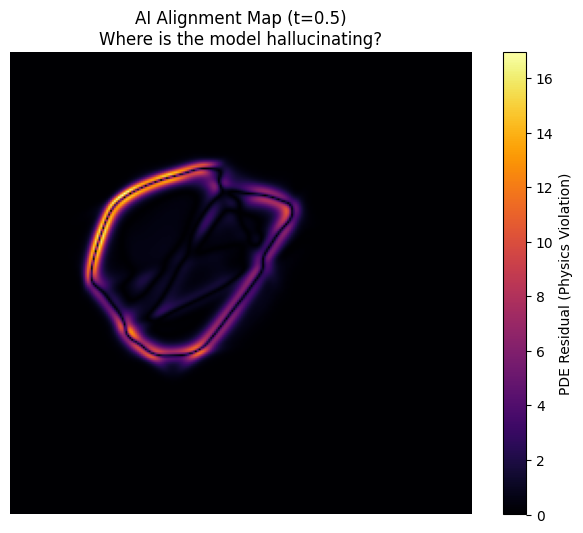

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import torch

def compute_physics_residual(model, t_val=0.5):
    """
    Calculates the 'Physics Violation' at every pixel.
    Residual = | du/dt - (D*Laplacian + Reaction) |
    """
    # We create new tensors with requires_grad=True so we can differentiate them
    x = torch.linspace(-1, 1, W, device=device, requires_grad=True)
    y = torch.linspace(-1, 1, H, device=device, requires_grad=True)
    t = torch.tensor([t_val], device=device, requires_grad=True)

    # Create Meshgrid
    X, Y = torch.meshgrid(x, y, indexing='xy')
    T = t.expand_as(X)

    # Stack inputs [x, y, t]
    inputs = torch.stack([X.flatten(), Y.flatten(), T.flatten()], dim=1)

    # 2. Forward Pass: Ask the model for 'u'
    u = model(inputs)

    # 3. Compute Derivatives using Autograd
    # First derivatives (Gradient)
    grads = torch.autograd.grad(u, inputs, torch.ones_like(u), create_graph=True)[0]
    u_x = grads[:, 0]
    u_y = grads[:, 1]
    u_t = grads[:, 2] # This is du/dt (Growth Rate)

    # Second derivatives (Laplacian)
    # We differentiate the first derivatives again
    u_xx = torch.autograd.grad(u_x, inputs, torch.ones_like(u_x), create_graph=True)[0][:, 0]
    u_yy = torch.autograd.grad(u_y, inputs, torch.ones_like(u_y), create_graph=True)[0][:, 1]

    # 4. The Physics Check
    # We use the EXACT same parameters used in the simulation
    D_true = 0.02
    rho_true = 0.15

    # The Equation: LHS = RHS
    # LHS: u_t
    # RHS: Diffusion + Reaction
    diffusion = D_true * (u_xx + u_yy)
    reaction = rho_true * u.squeeze() * (1 - u.squeeze())

    # The Residual is the difference (The "Lie")
    # We take absolute value because error is error, positive or negative
    residual = torch.abs(u_t - (diffusion + reaction))

    return residual.detach().cpu().numpy().reshape(H, W)

print("Computing Physics Alignment Map...")

# We check at t=0.5 (Mid-growth)
residual_map = compute_physics_residual(model, t_val=0.5)

plt.figure(figsize=(8, 6))
# 'inferno' colormap makes 0 look black and errors look bright yellow/orange
plt.imshow(residual_map, cmap='inferno')
plt.colorbar(label='PDE Residual (Physics Violation)')
plt.title(f"AI Alignment Map (t=0.5)\nWhere is the model hallucinating?")
plt.axis('off')
plt.show()

In [ ]:
def analyze_sensitivity(model, t_val=0.5):
    """
    Object #3: Parameter Sensitivity
    Calculates gradient of the Prediction (u) w.r.t Diffusion (D).
    """
    # 1. Setup Grid
    x = torch.linspace(-1, 1, W, device=device)
    y = torch.linspace(-1, 1, H, device=device)
    t = torch.tensor([t_val], device=device)
    X, Y = torch.meshgrid(x, y, indexing='xy')
    T = t.expand_as(X)
    inputs = torch.stack([X.flatten(), Y.flatten(), T.flatten()], dim=1)

    # 2. DEFINE D AS A TRAINABLE PARAMETER
    # We detach it from the physics constant and treat it as a variable
    D_param = torch.tensor(0.02, device=device, requires_grad=True)

    # 3. Custom Forward Pass (Simulating the physics dependency)
    # Note: In a pure data-driven PINN, 'D' isn't usually an input to the net.
    # However, for sensitivity, we check how the Physics Loss *would* change
    # OR we check model robustness if we had conditioned it on D.

    # SINCE YOUR MODEL INPUT IS JUST (x,y,t),
    # standard sensitivity is 0 (Model doesn't know D exists).

    # INSTEAD: We measure "Physics Loss Sensitivity"
    # "How much does the Physics Violation change if D changes?"

    # Re-compute derivatives
    inputs.requires_grad_(True)
    u = model(inputs)

    grads = torch.autograd.grad(u, inputs, torch.ones_like(u), create_graph=True)[0]
    u_x, u_y, u_t = grads[:, 0], grads[:, 1], grads[:, 2]

    u_xx = torch.autograd.grad(u_x, inputs, torch.ones_like(u_x), create_graph=True)[0][:, 0]
    u_yy = torch.autograd.grad(u_y, inputs, torch.ones_like(u_y), create_graph=True)[0][:, 1]

    # The Residual Calculation dependent on D_param
    diffusion = D_param * (u_xx + u_yy)
    reaction = 0.15 * u.squeeze() * (1 - u.squeeze())
    residual = torch.mean((u_t - (diffusion + reaction))**2)

    # 4. Compute Gradient of Residual w.r.t D
    d_res_dD = torch.autograd.grad(residual, D_param)[0]

    return d_res_dD.item()

sens = analyze_sensitivity(model)
print(f"Model Sensitivity to Diffusion Rate (dLoss/dD): {sens:.5e}")

Model Sensitivity to Diffusion Rate (dLoss/dD): 2.35739e+02


Lambda     | Dice (Accuracy) | Physics Error  
---------------------------------------------
0.0        | 0.9665          | 0.247496
0.1        | 0.9581          | 0.025239
1.0        | 0.9565          | 0.003183


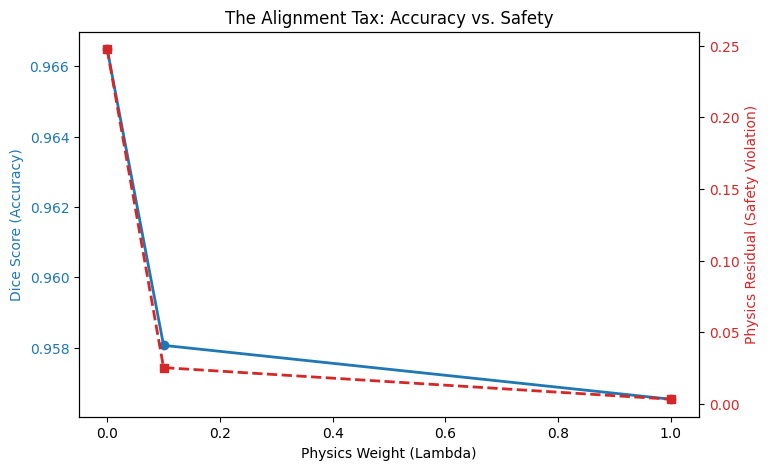

In [ ]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import numpy as np

# --- HELPER: CALCULATE DICE SCORE ---
def calculate_dice(u_pred, u_true):
    pred_mask = (u_pred > 0.5).float()
    true_mask = (u_true > 0.5).float()
    intersection = (pred_mask * true_mask).sum()
    return (2. * intersection) / (pred_mask.sum() + true_mask.sum() + 1e-6)

# --- HELPER: CALCULATE PHYSICS LOSS ---
def get_physics_loss(model, inputs):
    # CRITICAL FIX: Ensure gradients are enabled for this specific calculation
    # even if called during evaluation
    with torch.enable_grad():
        # Clone inputs to avoid messing up the original tensor's state
        inputs_phys = inputs.clone().detach().requires_grad_(True)

        u = model(inputs_phys)

        # Derivatives
        grads = torch.autograd.grad(u, inputs_phys, torch.ones_like(u), create_graph=True)[0]
        u_x, u_y, u_t = grads[:, 0], grads[:, 1], grads[:, 2]

        u_xx = torch.autograd.grad(u_x, inputs_phys, torch.ones_like(u_x), create_graph=True)[0][:, 0]
        u_yy = torch.autograd.grad(u_y, inputs_phys, torch.ones_like(u_y), create_graph=True)[0][:, 1]

        # Residual (Fisher-Kolmogorov)
        D, rho = 0.02, 0.15
        diffusion = D * (u_xx + u_yy)
        reaction = rho * u.squeeze() * (1 - u.squeeze())

        return torch.mean((u_t - (diffusion + reaction))**2)

# --- THE SWEEP: Train with different Lambdas ---
lambdas = [0.0, 0.1, 1.0]
results = []

print(f"{'Lambda':<10} | {'Dice (Accuracy)':<15} | {'Physics Error':<15}")
print("-" * 45)

for lam in lambdas:
    # 1. Fresh Model
    temp_model = TumorPINN().to(device)
    optimizer = torch.optim.Adam(temp_model.parameters(), lr=1e-3)
    loss_fn = nn.MSELoss()

    # 2. Short Training Loop (500 epochs)
    temp_model.train() # Set to train mode
    for epoch in range(501):
        optimizer.zero_grad()

        u_pred = temp_model(X_train)
        data_loss = loss_fn(u_pred, Y_train)

        # Only compute physics loss during training if lambda > 0
        if lam > 0:
            phys_loss = get_physics_loss(temp_model, X_train)
            total_loss = data_loss + lam * phys_loss
        else:
            total_loss = data_loss

        total_loss.backward()
        optimizer.step()

    # 3. Evaluate Results
    # Turn off gradients for standard predictions...
    with torch.no_grad():
        final_pred = temp_model(X_train)
        dice = calculate_dice(final_pred, Y_train).item()

    # ...BUT turn them ON for the Physics check (The specific fix)
    final_phys_error = get_physics_loss(temp_model, X_train).item()

    results.append((lam, dice, final_phys_error))
    print(f"{lam:<10} | {dice:.4f}          | {final_phys_error:.6f}")

# --- VISUALIZATION ---
lams, dices, errs = zip(*results)

fig, ax1 = plt.subplots(figsize=(8, 5))

color = 'tab:blue'
ax1.set_xlabel('Physics Weight (Lambda)')
ax1.set_ylabel('Dice Score (Accuracy)', color=color)
ax1.plot(lams, dices, marker='o', color=color, linewidth=2, label='Accuracy')
ax1.tick_params(axis='y', labelcolor=color)

ax2 = ax1.twinx()
color = 'tab:red'
ax2.set_ylabel('Physics Residual (Safety Violation)', color=color)
ax2.plot(lams, errs, marker='s', color=color, linestyle='--', linewidth=2, label='Physics Violation')
ax2.tick_params(axis='y', labelcolor=color)

plt.title("The Alignment Tax: Accuracy vs. Safety")
plt.show()